# Does a dead mite's image change between recordings?

**The hypothesis:** a dead mite lies as it is, so its image in one recording is its image in the next. A live one shifts a leg or turns between two recordings, even when it is still in both.

**The test:** in the long run (`test_run_2026-09-08_Mathis_last_dsRNA`, 295 recordings 10 minutes apart, every mite labelled in every recording) a mite still for 500 minutes does not move again. So a mite is taken as **dead from 500 minutes after its last labelled movement**, and each recording is compared with the next:

- **dead**: both recordings at least 500 minutes after the mite's last movement,
- **alive**: both recordings up to its last movement,
- **waiting**: the pairs in between, after the last movement but not yet 500 minutes.

The mites never labelled moving are left out: they may have been dead from the start.

The **change** between two recordings is the mean absolute difference, in grey levels, of the mite's mean image in each (`classes/recording_change.py`), after the plate's shift and the change of the light between the two are taken out. It is read against the **noise floor**: what two recordings of a mite that did nothing would differ by from the camera's noise alone, measured within each recording.

The patches are those `scripts/optuna_death_time.py` cuts and keeps in the system's temporary folder; the first run cuts them (slow), later ones start at once.

## Findings (run of 7 October 2026)

These are the numbers of the run saved in this notebook: one run, one plate, 54 mites that moved at least once. Change is in grey levels; a pair of recordings **changed** when it differs by more than 0.75, which the camera's noise alone reaches in 1 still recording in 1000.

- **A mite long dead does not change.** From 1000 minutes after its last movement, a mite's image differs from one recording to the next by 0.49 in the middle, which is the noise floor (0.48). 0.4% of those 7137 pairs changed.
- **A live mite does, even when it looks still.** 88% of the pairs up to the last movement changed (median 1.36). Of the pairs in which the mite was labelled still in *both* recordings, 83% changed: it moved in the 10 minutes in between. The change tells an alive pair from a dead one with an AUC of 0.98.
- **But 500 minutes after the last labelled movement is not yet dead for every mite.** 2.1% of the dead pairs changed (207 of 9837), and they are not spread out: 190 of them are in 10 mites, in runs that start before the 500 minutes and carry on. 12 of the 54 mites still have a changed pair between 500 and 600 minutes, 10 between 600 and 800; it is over by 800 to 1000 minutes (1.2% of the pairs).
- **The image goes on changing after the last labelled movement.** It last changed (two pairs in a row) 110 minutes after the last labelled movement in the middle, more than 500 minutes after it in 13 mites, and more than 1000 in 2. The pictures show legs in other places from one recording to the next. Whether that is a mite still alive, moving too slowly or too rarely to be caught in a recording of 0.7 seconds, or a dead one whose legs draw in, this notebook cannot tell.
- **The premise nearly holds in the labels.** Of 406 stretches of stillness between two labelled movements, the longest is 530 minutes, the only one above 500; 14 are of 300 minutes or more.
- **Over hours a dead mite drifts a little.** A long dead mite compared with itself 600 minutes on differs by 0.56 in the middle and 4.9% of the pairs changed, against 0.4% from one recording to the next. A live one changed in every such pair.
- **Three of the 5 mites never labelled moving change for the first hours** like the live ones: they were probably alive, and are left out of the survival numbers for want of a movement seen.

**What it means for the hypothesis:** it holds, with the death put where the image stops changing and not 500 minutes after the last labelled movement. The change between recordings is a sign of life the movement score does not have (it looks within one recording only), and it has a floor that is the same for every mite (0.42 to 0.56 in the middle, mite by mite). Not tried here: using it to place the deaths, or on a second run.


In [1]:
import os
import sys
import tempfile
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

import pipeline
from classes import calibration, recording_change
from classes.app_config import get_default_config
from classes.recording_change import RecordingChange
from optuna_death_time import MAX_PAD, load_dataset

# The project's reporting module switches matplotlib to Agg (no figures) on import.
%matplotlib inline

DEATH_MINUTES = 500  # a mite still for this long after its last movement is taken as dead
LONG_DEAD = 1000     # and as long dead from here on
MARGIN = 8           # pixels around a mite's box the plate's shift is measured with
JOBS = os.cpu_count()
CACHE = Path(tempfile.gettempdir()) / "varroa_death_time_patches"

# Chart style, as in death_time_calibration.ipynb: thin marks, recessive axes and grid, text in ink colours.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8d8c85"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3dc"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2,
})
COLORS = {"alive": ORANGE, "waiting": AQUA, "dead": BLUE}
pd.set_option("display.precision", 2)

## The long run

The longest dataset saved in `calibration_data/`, its detections marked *not a mite* left out. A recording not labelled counts as still.

In [2]:
saved = {summary["id"]: pipeline._read_dataset(summary["id"], pipeline.CALIBRATION_LIBRARY)
         for summary in pipeline.list_calibration_datasets()}
dataset_id = max(saved, key=lambda key: len(saved[key]["times"]))
times = np.array(saved[dataset_id]["times"], dtype=float)  # minutes from the first recording

CACHE.mkdir(parents=True, exist_ok=True)
dataset = load_dataset({"id": dataset_id}, CACHE, get_default_config().mite.stabilize_plate, JOBS)
patches = np.load(dataset["path"], mmap_mode="r")  # (mites, recordings, frames, side, side, channels)
moving, labelled, sizes = dataset["moving"], dataset["labelled"], dataset["sizes"]
n_mites, n_recordings = moving.shape

moved = moving.any(axis=1)
last = np.where(moved, n_recordings - 1 - np.argmax(moving[:, ::-1], axis=1), -1)  # last recording moving, -1 for none
print(f"{n_mites} mites, {n_recordings} recordings {np.median(np.diff(times)):g} minutes apart, "
      f"{patches.shape[2]} frames each; {(~labelled).sum()} of {labelled.size} recordings not labelled")
print(f"{moved.sum()} mites moved at least once, {(~moved).sum()} never; last movement: "
      f"half the mites by {np.median(times[last[moved]]) / 60:.1f} h, the last one at {times[last.max()] / 60:.1f} h "
      f"of {times[-1] / 60:.1f} h")

  test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings
59 mites, 295 recordings 10 minutes apart, 10 frames each; 87 of 17405 recordings not labelled
54 mites moved at least once, 5 never; last movement: half the mites by 8.8 h, the last one at 30.8 h of 49.0 h


### Is 500 minutes the longest a mite stays still before moving again?

The stretches without a labelled movement between two movements of the same mite.

406 stretches of stillness between two movements; the longest 530 minutes; 14 of 300 minutes or more
mites followed for 500 minutes or more after their last movement: 54 of 54


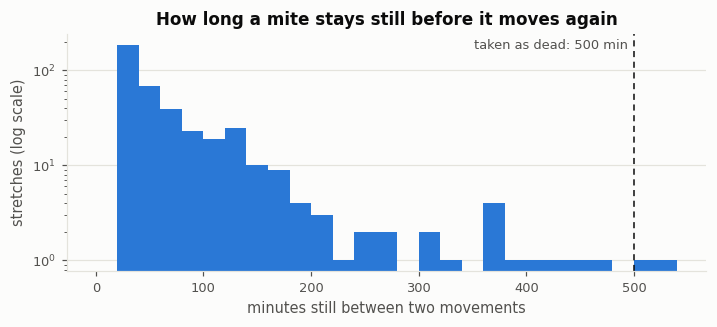

In [3]:
gaps = np.concatenate([np.diff(times[np.flatnonzero(row)]) for row in moving])
gaps = gaps[gaps > np.median(np.diff(times))]  # one recording to the next is no gap
print(f"{len(gaps)} stretches of stillness between two movements; the longest {gaps.max():g} minutes; "
      f"{(gaps >= 300).sum()} of 300 minutes or more")
print(f"mites followed for {DEATH_MINUTES} minutes or more after their last movement: "
      f"{(moved & (times[-1] - times[np.maximum(last, 0)] >= DEATH_MINUTES)).sum()} of {moved.sum()}")

fig, ax = plt.subplots(figsize=(7.5, 2.8))
ax.hist(gaps, bins=np.arange(0, 560, 20), color=BLUE)
ax.axvline(DEATH_MINUTES, color=INK, linewidth=1, linestyle=(0, (4, 3)))
ax.set_yscale("log")
ax.annotate(f"taken as dead: {DEATH_MINUTES} min", (DEATH_MINUTES, ax.get_ylim()[1]), xytext=(-4, -3),
            textcoords="offset points", ha="right", va="top", fontsize=8.5, color=MUTED)
ax.set(xlabel="minutes still between two movements", ylabel="stretches (log scale)",
       title="How long a mite stays still before it moves again")
ax.grid(axis="x", visible=False)
plt.show()

## The change between recordings

Each mite's image in a recording is the mean of its frames, in grey. `RecordingChange.changes()` compares each recording with the next. The noise floor of a pair is that of the noisier of its two recordings.

In [4]:
def cut(mite, margin):
    # the mite's patches with `margin` pixels around its box
    height, width = sizes[mite]
    edge = MAX_PAD - margin
    return np.asarray(patches[mite, :, :, edge:2 * MAX_PAD + height - edge, edge:2 * MAX_PAD + width - edge])

images = [recording_change.recording_images(cut(mite, MARGIN)) for mite in range(n_mites)]
floor = np.array([recording_change.noise_floor(cut(mite, 0)) for mite in range(n_mites)])  # (mites, recordings)
measure = RecordingChange(MARGIN)
change = measure.changes(images)                                                          # (mites, recordings - 1)
pair_floor = np.maximum(floor[:, :-1], floor[:, 1:])

group = recording_change.groups(moving, times, DEATH_MINUTES)
since = np.where(moved[:, None], times[None, :-1] - times[np.maximum(last, 0)][:, None], np.nan)  # minutes since the last movement
shifts = np.hypot(*measure.plate_shifts(images).T)
print(f"plate's shift between two recordings: median {np.median(shifts):.2f} px, largest {shifts.max():.2f} px")
print("pairs of recordings:", ", ".join(f"{name} {int(mask.sum())}" for name, mask in group.items()))

plate's shift between two recordings: median 0.05 px, largest 0.53 px
pairs of recordings: alive 3339, waiting 2700, dead 9837


### What counts as a change

A pair of recordings **changed** when it differs by more than the camera's noise makes a still recording differ from itself: the limit is the 99.9th percentile of the noise floor of the recordings labelled still.

In [5]:
still_floor = floor[labelled & ~moving]
LIMIT = float(np.percentile(still_floor, 99.9))
print(f"noise floor of a still recording: median {np.median(still_floor):.2f}, 99.9% below {LIMIT:.2f}: the limit; "
      f"of a moving one: median {np.median(floor[moving]):.2f}")

noise floor of a still recording: median 0.48, 99.9% below 0.75: the limit; of a moving one: median 0.60


## Dead, waiting and alive

The alive pairs are split by their labels: the mite labelled still in both recordings, or moving in at least one.

In [6]:
either_moving = moving[:, :-1] | moving[:, 1:]
long_dead = group["dead"] & (since >= LONG_DEAD)
rows = {"dead": group["dead"], f"dead, {LONG_DEAD} min or more": long_dead,
        "waiting": group["waiting"], "alive": group["alive"],
        "alive, still in both recordings": group["alive"] & ~either_moving,
        "alive, moving in one or both": group["alive"] & either_moving}

def describe(mask):
    values = change[mask]
    return {"pairs": int(mask.sum()), "mites": int(mask.any(axis=1).sum()), "median": np.median(values),
            "90%": np.percentile(values, 90), "99%": np.percentile(values, 99), "largest": values.max(),
            "noise floor (median)": np.median(pair_floor[mask]), "changed": (values > LIMIT).mean()}

table = pd.DataFrame({name: describe(mask) for name, mask in rows.items()}).T
display(table.style.format({"pairs": "{:.0f}", "mites": "{:.0f}", "changed": "{:.1%}"}, precision=2))

def auc(low, high):
    # the chance a pair of `high` changes more than one of `low`
    return calibration.auc(np.concatenate([change[low], change[high]]),
                           np.concatenate([np.zeros(low.sum(), bool), np.ones(high.sum(), bool)]))

print(f"telling an alive pair from a dead one by its change: AUC {auc(group['dead'], group['alive']):.3f}; "
      f"from a long dead one: {auc(long_dead, group['alive']):.3f}; "
      f"an alive pair labelled still in both from a long dead one: "
      f"{auc(long_dead, rows['alive, still in both recordings']):.3f}")

,pairs,mites,median,90%,99%,largest,noise floor (median),changed
dead,9837,54,0.48,0.58,1.03,3.14,0.54,2.1%
"dead, 1000 min or more",7137,54,0.49,0.58,0.69,2.08,0.55,0.4%
waiting,2700,54,0.53,1.23,2.38,5.15,0.48,28.6%
alive,3339,54,1.36,2.59,4.45,7.72,0.50,88.1%
"alive, still in both recordings",2301,54,1.19,2.22,4.34,7.72,0.48,83.2%
"alive, moving in one or both",1038,54,1.78,3.10,4.54,6.40,0.63,98.9%


telling an alive pair from a dead one by its change: AUC 0.980; from a long dead one: 0.985; an alive pair labelled still in both from a long dead one: 0.979


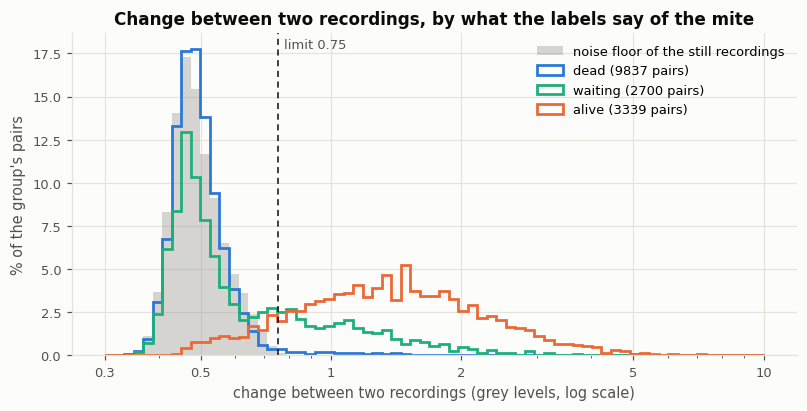

In [7]:
bins = np.geomspace(0.3, 10, 70)
fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.hist(still_floor, bins=bins, weights=np.full(len(still_floor), 100 / len(still_floor)), color=GREY, alpha=0.35,
        linewidth=0, label="noise floor of the still recordings")
for name in ("dead", "waiting", "alive"):
    ax.hist(change[group[name]], bins=bins, weights=np.full(group[name].sum(), 100 / group[name].sum()),
            histtype="step", linewidth=1.8, color=COLORS[name], label=f"{name} ({group[name].sum()} pairs)")
ax.axvline(LIMIT, color=INK, linewidth=1, linestyle=(0, (4, 3)))
ax.annotate(f"limit {LIMIT:.2f}", (LIMIT, ax.get_ylim()[1]), xytext=(4, -3), textcoords="offset points", va="top",
            fontsize=8.5, color=MUTED)
ax.set_xscale("log")
ax.set_xticks([0.3, 0.5, 1, 2, 5, 10], labels=["0.3", "0.5", "1", "2", "5", "10"])
ax.set(xlabel="change between two recordings (grey levels, log scale)", ylabel="% of the group's pairs",
       title="Change between two recordings, by what the labels say of the mite")
ax.legend()
plt.show()

## The change around the last movement

Every pair of recordings by the time since the mite's last labelled movement (negative: before it). If the hypothesis held from the last movement on, the change would fall to the noise floor there.

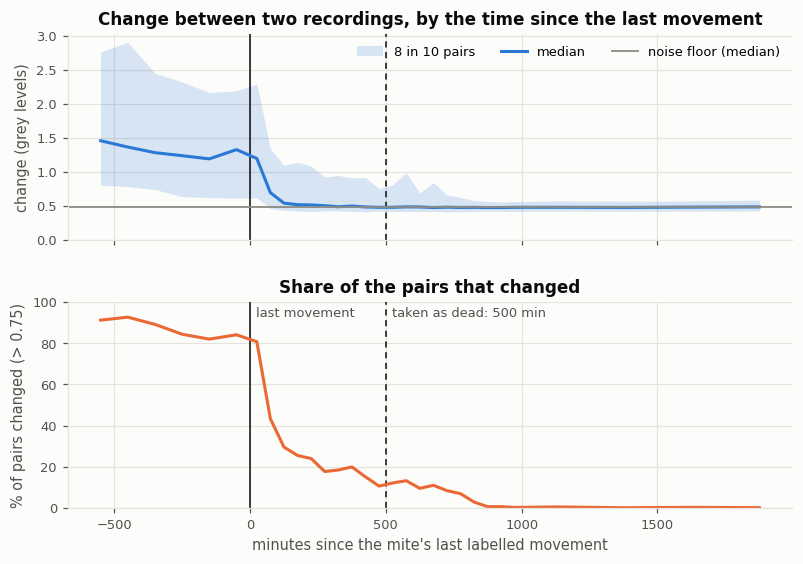

minutes since the last movement,pairs,mites with a changed pair,of mites,pairs changed
before it,3339,54,54,88.1%
0 to 100,540,52,54,62.0%
100 to 300,1080,29,54,24.3%
300 to 500,1080,18,54,16.1%
500 to 600,540,12,54,12.8%
600 to 800,1080,10,54,9.1%
800 to 1000,1080,4,54,1.2%
1000 to 1500,2579,6,54,0.4%
1500 to 3000,4558,4,51,0.4%


In [8]:
edges = np.concatenate([np.arange(-600, 0, 100), np.arange(0, 1000, 50), np.arange(1000, 2001, 250)])
middle, median, low, high, share = [], [], [], [], []
for start, end in zip(edges[:-1], edges[1:]):
    values = change[(since >= start) & (since < end)]
    middle.append((start + end) / 2)
    median.append(np.median(values)); low.append(np.percentile(values, 10)); high.append(np.percentile(values, 90))
    share.append(100 * (values > LIMIT).mean())

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(8.5, 5.6), sharex=True, gridspec_kw={"hspace": 0.3})
ax.fill_between(middle, low, high, color=BLUE, alpha=0.18, linewidth=0, label="8 in 10 pairs")
ax.plot(middle, median, color=BLUE, label="median")
ax.axhline(np.median(still_floor), color=GREY, linewidth=1.2, label="noise floor (median)")
ax.set(ylabel="change (grey levels)", title="Change between two recordings, by the time since the last movement",
       ylim=(0, None))
ax.legend(loc="upper right", ncols=3)
ax2.plot(middle, share, color=ORANGE)
ax2.set(xlabel="minutes since the mite's last labelled movement", ylabel=f"% of pairs changed (> {LIMIT:.2f})",
        title="Share of the pairs that changed", ylim=(0, 100))
for axis in (ax, ax2):
    axis.axvline(0, color=INK, linewidth=1, zorder=1)
    axis.axvline(DEATH_MINUTES, color=INK, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax2.annotate("last movement", (0, 100), xytext=(4, -3), textcoords="offset points", va="top", fontsize=8.5, color=MUTED)
ax2.annotate(f"taken as dead: {DEATH_MINUTES} min", (DEATH_MINUTES, 100), xytext=(4, -3), textcoords="offset points",
             va="top", fontsize=8.5, color=MUTED)
plt.show()

display(pd.DataFrame([{"minutes since the last movement": f"{start} to {end}" if start > -10000 else "before it",
                       "pairs": int(mask.sum()),
                       "mites with a changed pair": int((mask & (change > LIMIT)).any(axis=1).sum()),
                       "of mites": int(mask.any(axis=1).sum()), "pairs changed": (change[mask] > LIMIT).mean()}
                      for start, end in ((-10000, 0), (0, 100), (100, 300), (300, 500), (500, 600), (600, 800),
                                         (800, 1000), (1000, 1500), (1500, 3000))
                      for mask in [(since >= start) & (since < end)]]).style.format({"pairs changed": "{:.1%}"}).hide(axis="index"))

## Every mite

One row per mite, sorted by its last labelled movement; the colour is the change from each recording to the next. The black line is the last movement, the dashed one 500 minutes later. The mites at the bottom, without a line, never moved.

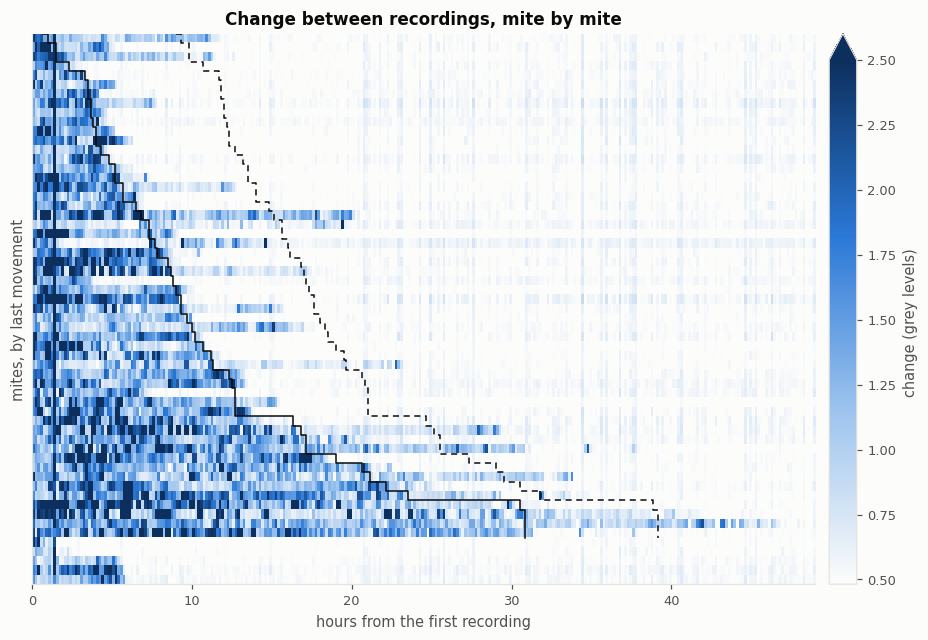

mite never labelled moving,pairs changed,of them in the first 6 hours,of pairs then
7,8,8,36
17,8,8,36
33,25,25,36
54,33,33,36
58,34,34,36


In [9]:
order = np.argsort(np.where(moved, last, n_recordings), kind="stable")  # the mites that never moved at the bottom
shade = LinearSegmentedColormap.from_list("change", ["#fcfcfb", "#9cc3ee", BLUE, "#0d2f5e"])
hours = times / 60
fig, ax = plt.subplots(figsize=(11, 6.5))
drawn = ax.imshow(change[order], aspect="auto", cmap=shade, vmin=np.median(still_floor), vmax=2.5,
                  interpolation="nearest", extent=(hours[0], hours[-1], n_mites, 0))
n_moved = int(moved.sum())
for offset, style in ((0, "-"), (DEATH_MINUTES / 60, (0, (4, 3)))):
    ax.step(np.append(hours[last[order][:n_moved]] + offset, hours[last[order][n_moved - 1]] + offset),
            np.arange(n_moved + 1), color=INK, linewidth=1, linestyle=style, where="post")
ax.set(xlabel="hours from the first recording", ylabel="mites, by last movement", yticks=[],
       title="Change between recordings, mite by mite", xlim=(hours[0], hours[-1]))
ax.grid(visible=False)
fig.colorbar(drawn, ax=ax, pad=0.015, label="change (grey levels)", extend="max")
plt.show()

never = np.flatnonzero(~moved)
display(pd.DataFrame({"mite never labelled moving": [dataset["mites"][m] for m in never],
                      "pairs changed": (change[never] > LIMIT).sum(axis=1),
                      "of them in the first 6 hours": (change[never][:, hours[:-1] < 6] > LIMIT).sum(axis=1),
                      "of pairs then": int((hours[:-1] < 6).sum())}).style.hide(axis="index"))

## When does a mite's image stop changing?

Per mite, the last pair of recordings that changed with the pair before it changed too (one changed pair alone may be anything: a mite walking past, a speck of dust). It is set against the last labelled movement.

of the 54 mites that moved, the image last changed after the last labelled movement in 52; by more than 500 minutes in 13, by more than 1000 in 2
minutes from the last movement to the last change: median 110, 8 in 10 mites between 33 and 755, most 1730
minutes without change at the end of the run: least 150, median 2260; 1 mites less than 500


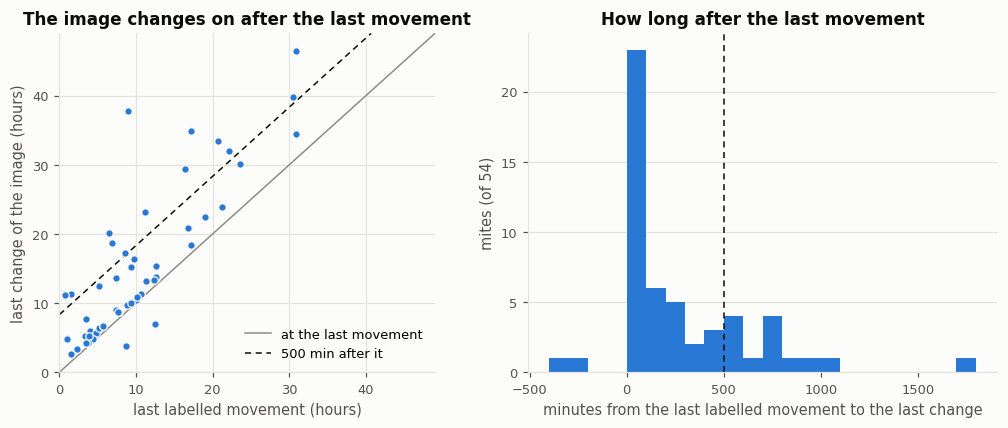

In [10]:
changed = change > LIMIT
in_a_row = changed[:, 1:] & changed[:, :-1]
# the later recording of that pair; the first recording for a mite whose image never changed
last_change = np.where(in_a_row.any(axis=1), n_recordings - 1 - np.argmax(in_a_row[:, ::-1], axis=1), 0)
later = (times[last_change] - times[np.maximum(last, 0)])[moved]  # minutes from the last movement to the last change

print(f"of the {moved.sum()} mites that moved, the image last changed after the last labelled movement in "
      f"{(later > 0).sum()}; by more than {DEATH_MINUTES} minutes in {(later > DEATH_MINUTES).sum()}, "
      f"by more than {LONG_DEAD} in {(later > LONG_DEAD).sum()}")
print(f"minutes from the last movement to the last change: median {np.median(later):.0f}, "
      f"8 in 10 mites between {np.percentile(later, 10):.0f} and {np.percentile(later, 90):.0f}, most {later.max():.0f}")
quiet = (times[-1] - times[last_change])[moved]
print(f"minutes without change at the end of the run: least {quiet.min():.0f}, median {np.median(quiet):.0f}; "
      f"{(quiet < DEATH_MINUTES).sum()} mites less than {DEATH_MINUTES}")

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [4, 5], "wspace": 0.22})
ax.plot([0, hours[-1]], [0, hours[-1]], color=GREY, linewidth=1, label="at the last movement")
ax.plot([0, hours[-1] - DEATH_MINUTES / 60], [DEATH_MINUTES / 60, hours[-1]], color=INK, linewidth=1,
        linestyle=(0, (4, 3)), label=f"{DEATH_MINUTES} min after it")
ax.scatter(hours[last[moved]], hours[last_change[moved]], s=24, color=BLUE, edgecolor="#fcfcfb", linewidth=0.8, zorder=3)
ax.set(xlabel="last labelled movement (hours)", ylabel="last change of the image (hours)",
       title="The image changes on after the last movement", xlim=(0, hours[-1]), ylim=(0, hours[-1]))
ax.legend(loc="lower right")
ax2.hist(later, bins=np.arange(100 * np.floor(later.min() / 100), later.max() + 100, 100), color=BLUE)
ax2.axvline(DEATH_MINUTES, color=INK, linewidth=1, linestyle=(0, (4, 3)))
ax2.set(xlabel="minutes from the last labelled movement to the last change", ylabel=f"mites (of {moved.sum()})",
        title="How long after the last movement")
ax2.grid(axis="x", visible=False)
plt.show()

## The dead pairs that changed

The mites with the most changed pairs among their dead ones, and what those look like: each mite's image from 500 minutes after its last movement on, every other recording, with the change to the next recording below it (black when above the limit).

207 of 9837 dead pairs changed, in 18 of 54 mites; 13 mites have more than 2, and 190 of them are in 10 mites


mite,last movement (h),dead pairs,changed,"last of them, minutes after the last movement"
10,17.2,141,32,1220
30,30.8,59,32,930
47,6.5,205,30,810
0,20.7,120,23,780
9,16.3,146,20,1220
46,0.7,240,13,620
32,9.0,190,10,2230
59,6.8,203,10,750
39,11.2,177,10,710
52,3.5,223,10,2720


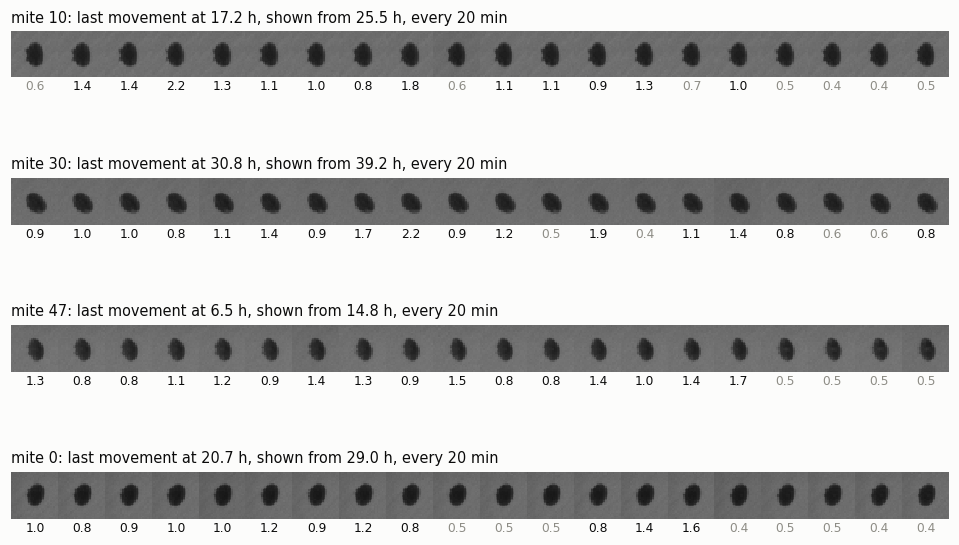

In [11]:
dead_changed = group["dead"] & changed
per_mite = pd.DataFrame({"mite": dataset["mites"], "last movement (h)": np.where(moved, hours[np.maximum(last, 0)], np.nan),
                         "dead pairs": group["dead"].sum(axis=1), "changed": dead_changed.sum(axis=1),
                         "last of them, minutes after the last movement":
                             [since[m][dead_changed[m]].max() if dead_changed[m].any() else np.nan for m in range(n_mites)]})
print(f"{dead_changed.sum()} of {group['dead'].sum()} dead pairs changed, in {dead_changed.any(axis=1).sum()} of "
      f"{group['dead'].any(axis=1).sum()} mites; {(per_mite['changed'] > 2).sum()} mites have more than 2, "
      f"and {per_mite['changed'].nlargest(10).sum()} of them are in 10 mites")
worst = per_mite.sort_values("changed", ascending=False).head(12)
display(worst.style.format({"last movement (h)": "{:.1f}", "last of them, minutes after the last movement": "{:.0f}"}).hide(axis="index"))

def strip(ax, mite, start, step=2, count=20):
    shown = list(range(start, min(start + step * count, n_recordings), step))
    colour = np.clip(np.asarray(patches[mite, shown, 0])[..., ::-1] / 255, 0, 1)  # first frame of each, BGR to RGB
    height, width = sizes[mite]
    colour = colour[:, MAX_PAD - MARGIN:MAX_PAD + height + MARGIN, MAX_PAD - MARGIN:MAX_PAD + width + MARGIN]
    ax.imshow(np.concatenate(list(colour), axis=1), interpolation="nearest")
    for index, at in enumerate(shown):
        if at < n_recordings - 1:
            ax.text((index + 0.5) * colour.shape[2], colour.shape[1] + 1, f"{change[mite, at]:.1f}", ha="center", va="top",
                    fontsize=8, color=INK if change[mite, at] > LIMIT else GREY)
    ax.set_title(f"mite {dataset['mites'][mite]}: last movement at {hours[last[mite]]:.1f} h, shown from "
                 f"{hours[start]:.1f} h, every {step * np.median(np.diff(times)):g} min", loc="left", fontsize=9.5,
                 fontweight="normal")
    ax.axis("off")

shown_mites = worst.index[:4]
fig, axes = plt.subplots(len(shown_mites), 1, figsize=(11, 1.55 * len(shown_mites)), gridspec_kw={"hspace": 0.75})
for ax, mite in zip(axes, shown_mites):
    strip(ax, mite, int(np.flatnonzero(group["dead"][mite])[0]))
plt.show()

## Over a longer time

A long dead mite (1000 minutes or more after its last movement) compared with itself further and further on: does it stay the same for hours, or does its image drift? Next to it, a live mite over the same time.

In [12]:
step = float(np.median(np.diff(times)))
rows = []
for lag in (1, 6, 30, 60):
    apart = change if lag == 1 else measure.changes(images, lag)
    dead_pairs = moved[:, None] & (times[None, :n_recordings - lag] - times[np.maximum(last, 0)][:, None] >= LONG_DEAD)
    alive_pairs = moved[:, None] & (np.arange(lag, n_recordings)[None] <= last[:, None])
    rows.append({"minutes apart": lag * step, "long dead pairs": int(dead_pairs.sum()),
                 "median": np.median(apart[dead_pairs]), "99%": np.percentile(apart[dead_pairs], 99),
                 "changed": (apart[dead_pairs] > LIMIT).mean(), "alive pairs": int(alive_pairs.sum()),
                 "alive: median": np.median(apart[alive_pairs]), "alive: changed": (apart[alive_pairs] > LIMIT).mean()})
display(pd.DataFrame(rows).style.format({"minutes apart": "{:g}", "changed": "{:.1%}", "alive: changed": "{:.1%}"},
                                        precision=2).hide(axis="index"))

minutes apart,long dead pairs,median,99%,changed,alive pairs,alive: median,alive: changed
10,7137,0.49,0.69,0.4%,3339,1.36,88.1%
60,6867,0.49,0.73,0.7%,3070,1.69,94.6%
300,5629,0.50,1.10,3.3%,1934,2.41,99.7%
600,4105,0.56,1.45,4.9%,996,2.73,100.0%
